# 1. Implement key probability distributions in code and analyze their differences

## Step 1 — Load the Dataset

In [9]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("GaltonFamilies.csv")

# Extract heights
father_heights = df["father"].values
child_heights = df["childHeight"].values

# Combine into one unlabeled dataset
data = np.concatenate((father_heights, child_heights))

# Convert to column vector
X = data.reshape(-1,1)

print("Number of samples:", len(X))

Number of samples: 1868


## Step 2 — Initialize Parameters

In [2]:
# Initial means
mu1 = np.min(X)
mu2 = np.max(X)

# Initial standard deviations
sigma1 = np.std(X)
sigma2 = np.std(X)

# Mixing coefficients
pi1 = 0.5
pi2 = 0.5

## Step 3 — Gaussian Function

In [3]:
def gaussian(x, mu, sigma):
    coefficient = 1 / (np.sqrt(2 * np.pi) * sigma)
    exponent = np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))
    return coefficient * exponent

## Step 4 — Expectation Step

In [5]:
def expectation(X, mu1, mu2, sigma1, sigma2, pi1, pi2):

    p1 = pi1 * gaussian(X, mu1, sigma1)
    p2 = pi2 * gaussian(X, mu2, sigma2)

    gamma1 = p1 / (p1 + p2)
    gamma2 = p2 / (p1 + p2)

    return gamma1, gamma2

## Step 5 — Maximization Step

In [6]:
def maximization(X, gamma1, gamma2):

    N1 = np.sum(gamma1)
    N2 = np.sum(gamma2)

    mu1 = np.sum(gamma1 * X) / N1
    mu2 = np.sum(gamma2 * X) / N2

    sigma1 = np.sqrt(np.sum(gamma1 * (X - mu1) ** 2) / N1)
    sigma2 = np.sqrt(np.sum(gamma2 * (X - mu2) ** 2) / N2)

    pi1 = N1 / len(X)
    pi2 = N2 / len(X)

    return mu1, mu2, sigma1, sigma2, pi1, pi2

## Step 6 — Log Likelihood

In [7]:
def log_likelihood(X, mu1, mu2, sigma1, sigma2, pi1, pi2):

    likelihood = (
        pi1 * gaussian(X, mu1, sigma1)
        + pi2 * gaussian(X, mu2, sigma2)
    )

    return np.sum(np.log(likelihood))

## Step 7 — EM Loop

In [8]:
iterations = 30

print("Iteration\tmu1\tmu2\tsigma1\tsigma2\tpi1\tpi2\tLogLikelihood")

for i in range(iterations):

    gamma1, gamma2 = expectation(
        X,
        mu1,
        mu2,
        sigma1,
        sigma2,
        pi1,
        pi2
    )

    mu1, mu2, sigma1, sigma2, pi1, pi2 = maximization(
        X,
        gamma1,
        gamma2
    )

    ll = log_likelihood(
        X,
        mu1,
        mu2,
        sigma1,
        sigma2,
        pi1,
        pi2
    )

    print(
        i,
        round(float(mu1),2),
        round(float(mu2),2),
        round(float(sigma1),2),
        round(float(sigma2),2),
        round(float(pi1),2),
        round(float(pi2),2),
        round(float(ll),2),
        sep="\t"
    )

Iteration	mu1	mu2	sigma1	sigma2	pi1	pi2	LogLikelihood
0	64.83	70.17	2.15	1.91	0.41	0.59	-4894.57
1	64.92	70.05	2.31	2.03	0.4	0.6	-4875.31
2	64.97	69.97	2.41	2.11	0.4	0.6	-4868.93
3	65.01	69.91	2.47	2.16	0.4	0.6	-4866.14
4	65.04	69.87	2.51	2.19	0.39	0.61	-4864.71
5	65.05	69.83	2.54	2.22	0.39	0.61	-4863.92
6	65.06	69.81	2.57	2.24	0.39	0.61	-4863.45
7	65.07	69.79	2.58	2.26	0.39	0.61	-4863.15
8	65.08	69.77	2.6	2.27	0.38	0.62	-4862.95
9	65.08	69.75	2.61	2.28	0.38	0.62	-4862.82
10	65.08	69.74	2.61	2.29	0.38	0.62	-4862.73
11	65.08	69.73	2.62	2.29	0.38	0.62	-4862.66
12	65.07	69.72	2.62	2.3	0.38	0.62	-4862.6
13	65.07	69.71	2.63	2.31	0.38	0.62	-4862.56
14	65.07	69.71	2.63	2.31	0.37	0.63	-4862.53
15	65.06	69.7	2.63	2.31	0.37	0.63	-4862.5
16	65.06	69.69	2.63	2.32	0.37	0.63	-4862.47
17	65.05	69.69	2.63	2.32	0.37	0.63	-4862.45
18	65.04	69.68	2.63	2.32	0.37	0.63	-4862.42
19	65.04	69.68	2.63	2.32	0.37	0.63	-4862.4
20	65.03	69.68	2.63	2.33	0.37	0.63	-4862.38
21	65.02	69.67	2.62	2.33	0.37	0.63	-4862.36


## Step 8 — Classify a New Height

In [10]:
height = float(input("Enter a height: "))

p1 = pi1 * gaussian(height, mu1, sigma1)
p2 = pi2 * gaussian(height, mu2, sigma2)

total = p1 + p2

print("\nPosterior Probabilities")
print("-----------------------")
print("Child Probability :", round(float(p1/total),4))
print("Father Probability:", round(float(p2/total),4))

Enter a height:  72.0



Posterior Probabilities
-----------------------
Child Probability : 0.0211
Father Probability: 0.9789


# 2. Apply Baesian Probability to real-world problem

## Step 1: Bayes' Theorem

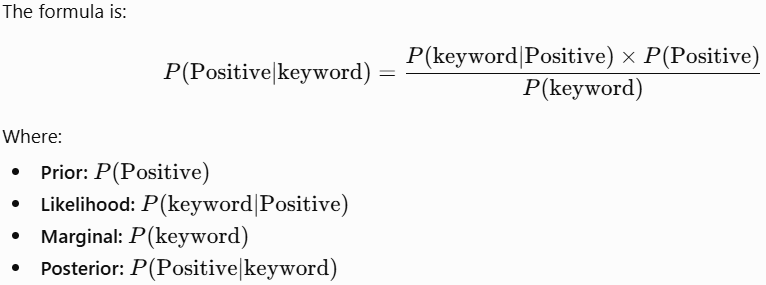

## Step 2: Python Implementation

In [11]:
import pandas as pd
import re

# Load dataset
df = pd.read_csv("IMDB Dataset.csv")

# Choose keywords
keywords = ["excellent", "amazing", "wonderful"]

# Prior probability
positive_reviews = df[df["sentiment"] == "positive"]
P_positive = len(positive_reviews) / len(df)

print(f"Prior P(Positive) = {P_positive:.4f}\n")

print("-" * 70)
print(f"{'Keyword':<12}{'P(keyword|Positive)':<22}{'P(keyword)':<18}{'P(Positive|keyword)'}")
print("-" * 70)

for keyword in keywords:

    # Reviews containing keyword
    contains_keyword = df["review"].str.contains(
        rf"\b{re.escape(keyword)}\b",
        case=False,
        regex=True
    )

    # Marginal probability
    P_keyword = contains_keyword.mean()

    # Likelihood
    P_keyword_given_positive = (
        (contains_keyword & (df["sentiment"] == "positive")).sum()
        / len(positive_reviews)
    )

    # Bayes theorem
    P_positive_given_keyword = (
        P_keyword_given_positive * P_positive
    ) / P_keyword

    print(
        f"{keyword:<12}"
        f"{P_keyword_given_positive:<22.4f}"
        f"{P_keyword:<18.4f}"
        f"{P_positive_given_keyword:.4f}"
    )

Prior P(Positive) = 0.5000

----------------------------------------------------------------------
Keyword     P(keyword|Positive)   P(keyword)        P(Positive|keyword)
----------------------------------------------------------------------
excellent   0.1147                0.0710            0.8074
amazing     0.0672                0.0432            0.7780
wonderful   0.0903                0.0556            0.8122


# 4. Convert manual gradient descent calculations into Python code

## Step 1: Import Libraries

In [6]:
from scipy.optimize import approx_fprime
import matplotlib.pyplot as plt

## Step 2: Define the Dataset

In [10]:
X = np.array([[1, 3],
              [4, 10]], dtype=float)
target = np.array([5, 6], dtype=float)

m = np.array([-1.0, 2.0])
b = 1.0
lr = 0.01
n = X.shape[0]
n_iterations = 3

## Step 3: Prediction Function

In [11]:
def predict(m, b, X):
    """y_hat = X . m + b   (matrix multiplication, not element-by-element)."""
    return X.dot(m) + b

def cost_J(params, X, target):
    """MSE cost: J = (1/n) * sum((y_hat - target)^2)."""
    m_ = params[:2]
    b_ = params[2]
    y_hat = predict(m_, b_, X)
    error = y_hat - target
    return np.mean(error ** 2)

In [12]:
def analytical_gradient(m, b, X, target):
    y_hat = predict(m, b, X)
    error = y_hat - target
    grad_m = (2 / n) * X.T.dot(error)
    grad_b = (2 / n) * np.sum(error)
    return grad_m, grad_b, error, y_hat

In [13]:
def scipy_gradient(m, b, X, target, epsilon=1e-6):
    params = np.array([m[0], m[1], b])
    grad = approx_fprime(params, cost_J, epsilon, X, target)
    return grad[:2], grad[2]

In [14]:
history_m = [m.copy()]
history_b = [b]
history_error = []

print("=" * 70)
print("GRADIENT DESCENT - PART 4 (Python reproduction of manual Part 3)")
print("=" * 70)

for i in range(1, n_iterations + 1):
    print(f"\n--- Iteration {i} ---")
    print(f"Current m = {m}, b = {b}")

    # Step 1: Predict
    y_hat = predict(m, b, X)
    print(f"Prediction y_hat = X . m + b = {y_hat}")

    # Step 2: Error
    error = y_hat - target
    print(f"Error e = y_hat - target = {error}")

    # Step 3: MSE cost (for the error-vs-iteration plot)
    mse = np.mean(error ** 2)
    history_error.append(mse)
    print(f"MSE cost J = {mse:.4f}")

    # Step 4: Analytical gradient
    grad_m, grad_b, _, _ = analytical_gradient(m, b, X, target)
    print(f"Analytical gradient  -> grad_m = {grad_m}, grad_b = {grad_b}")

    # Step 5: SciPy numerical gradient (sanity check against analytical one)
    grad_m_scipy, grad_b_scipy = scipy_gradient(m, b, X, target)
    print(f"SciPy numerical grad -> grad_m = {np.round(grad_m_scipy, 4)}, "
          f"grad_b = {grad_b_scipy:.4f}  (should match analytical)")

    # Step 6: Update m and b
    m = m - lr * grad_m
    b = b - lr * grad_b
    print(f"Updated  -> m = {np.round(m, 4)}, b = {round(b, 4)}")

    history_m.append(m.copy())
    history_b.append(b)

# Final MSE after the last update (for a complete error curve)
final_pred = predict(m, b, X)
final_error = final_pred - target
history_error.append(np.mean(final_error ** 2))

print("\n" + "=" * 70)
print(f"FINAL PARAMETERS after {n_iterations} iterations:")
print(f"m = {np.round(m, 4)}")
print(f"b = {round(b, 4)}")
print(f"Final predictions y_hat = {np.round(final_pred, 4)}")
print("=" * 70)

history_m = np.array(history_m)

GRADIENT DESCENT - PART 4 (Python reproduction of manual Part 3)

--- Iteration 1 ---
Current m = [-1.  2.], b = 1.0
Prediction y_hat = X . m + b = [ 6. 17.]
Error e = y_hat - target = [ 1. 11.]
MSE cost J = 61.0000
Analytical gradient  -> grad_m = [ 45. 113.], grad_b = 12.0
SciPy numerical grad -> grad_m = [ 45.     113.0001], grad_b = 12.0000  (should match analytical)
Updated  -> m = [-1.45  0.87], b = 0.88

--- Iteration 2 ---
Current m = [-1.45  0.87], b = 0.88
Prediction y_hat = X . m + b = [2.04 3.78]
Error e = y_hat - target = [-2.96 -2.22]
MSE cost J = 6.8450
Analytical gradient  -> grad_m = [-11.84 -31.08], grad_b = -5.1800000000000015
SciPy numerical grad -> grad_m = [-11.84   -31.0799], grad_b = -5.1800  (should match analytical)
Updated  -> m = [-1.3316  1.1808], b = 0.9318

--- Iteration 3 ---
Current m = [-1.3316  1.1808], b = 0.9318
Prediction y_hat = X . m + b = [3.1426 7.4134]
Error e = y_hat - target = [-1.8574  1.4134]
MSE cost J = 2.7238
Analytical gradient  -> gra

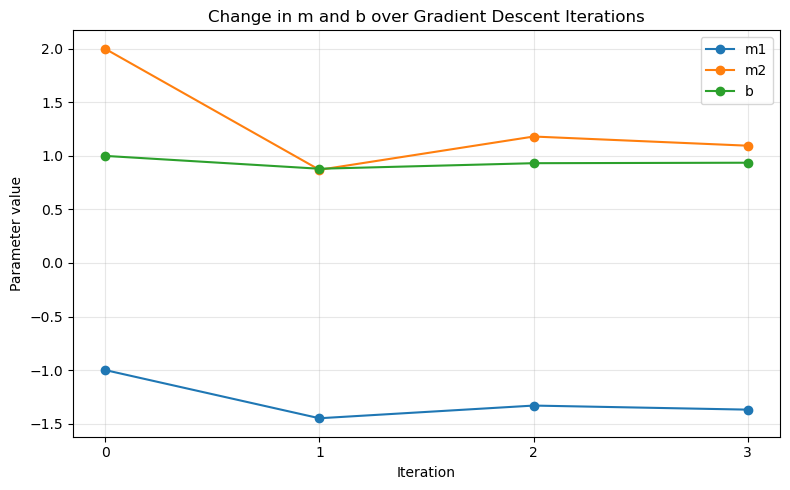

In [17]:
iterations = np.arange(len(history_b))   # 0, 1, 2, ..., n_iterations
plt.figure(figsize=(8, 5))
plt.plot(iterations, history_m[:, 0], marker='o', label='m1')
plt.plot(iterations, history_m[:, 1], marker='o', label='m2')
plt.plot(iterations, history_b, marker='o', label='b')
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Change in m and b over Gradient Descent Iterations')
plt.xticks(iterations)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('params_over_iterations.png', dpi=150)
plt.show()
plt.close()

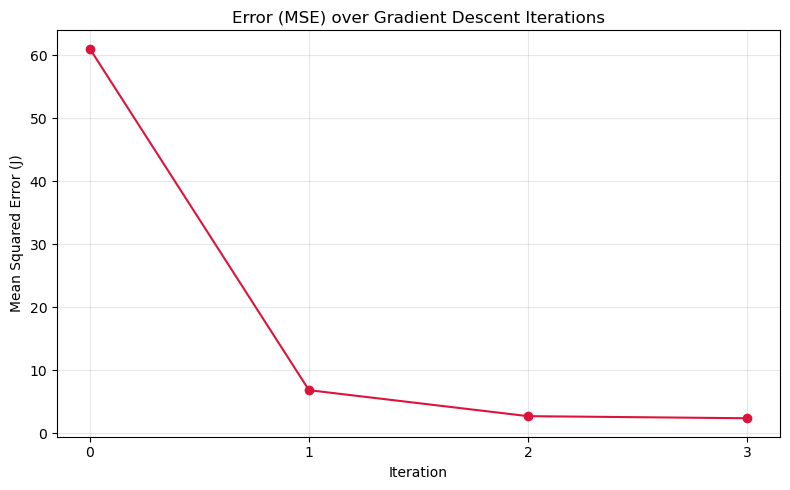

In [18]:

plt.figure(figsize=(8, 5))
plt.plot(iterations, history_error, marker='o', color='crimson')
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error (J)')
plt.title('Error (MSE) over Gradient Descent Iterations')
plt.xticks(iterations)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_over_iterations.png', dpi=150)
plt.show()
plt.close()